In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [2]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [3]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.8, 0.40, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)
m_g_array_rise_fall = rise_fall(t_array, 2, 8)
m_g_array_rise_fall /= np.trapezoid(m_g_array_rise_fall, t_array)

#etas = [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5]
etas = [0, 0.5, 1, 1.5, 2]
Upsilons = [1, 1.25, 1.5, 1.75, 2, 2.25]
#tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
tau_stars = [0.5, 1, 2, 4, 6]
gcc_Mn_this_notebook = 0.40
gcc_ratio_this_notebook = 2
alpha_cc_this_notebook = 0.60
alpha_ia_this_notebook = 0.30
m_g_array_this_notebook = m_g_array_rise_fall

In [4]:
 #First letter is Upsilon (A = 1) second letter is gcc_Mn (A = 0.25, E = 0.45)
alpha_ia_AA = 0.0
alpha_ia_AB = 0.2
alpha_ia_AC = 0.3
alpha_ia_AD = 0.6
alpha_ia_AE = 1.0

alpha_ias = [alpha_ia_AA, alpha_ia_AB, alpha_ia_AC, alpha_ia_AD, alpha_ia_AE]


#####
gals_AA = []
for i in range(len(etas)):
    gals_eta_j = []
    for j in range(len(tau_stars)):
        gals_eta_j.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_this_notebook, tau_star=tau_stars[j],
                                     eta=etas[i], Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook,
                                     alpha_cc_Mn=alpha_cc_this_notebook, alpha_Ia_Mn=alpha_ia_AA))
    gals_AA.append(gals_eta_j)
#####

#####
gals_AB = []
for i in range(len(etas)):
    gals_eta_j = []
    for j in range(len(tau_stars)):
        gals_eta_j.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_this_notebook, tau_star=tau_stars[j],
                                     eta=etas[i], Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook,
                                     alpha_cc_Mn=alpha_cc_this_notebook, alpha_Ia_Mn=alpha_ia_AB))
    gals_AB.append(gals_eta_j)
#####

#####
gals_AC = []
for i in range(len(etas)):
    gals_eta_j = []
    for j in range(len(tau_stars)):
        gals_eta_j.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_this_notebook, tau_star=tau_stars[j],
                                     eta=etas[i], Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook,
                                     alpha_cc_Mn=alpha_cc_this_notebook, alpha_Ia_Mn=alpha_ia_AC))
    gals_AC.append(gals_eta_j)
#####
#####
gals_AD = []
for i in range(len(etas)):
    gals_eta_j = []
    for j in range(len(tau_stars)):
        gals_eta_j.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_this_notebook, tau_star=tau_stars[j],
                                     eta=etas[i], Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook,
                                     alpha_cc_Mn=alpha_cc_this_notebook, alpha_Ia_Mn=alpha_ia_AD))
    gals_AD.append(gals_eta_j)
#####
#####
gals_AE = []
for i in range(len(etas)):
    gals_eta_j = []
    for j in range(len(tau_stars)):
        gals_eta_j.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_this_notebook, tau_star=tau_stars[j],
                                     eta=etas[i], Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_this_notebook, g_ratio_Mn=gcc_ratio_this_notebook,
                                     alpha_cc_Mn=alpha_cc_this_notebook, alpha_Ia_Mn=alpha_ia_AE))
    gals_AE.append(gals_eta_j)
#####

In [5]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals

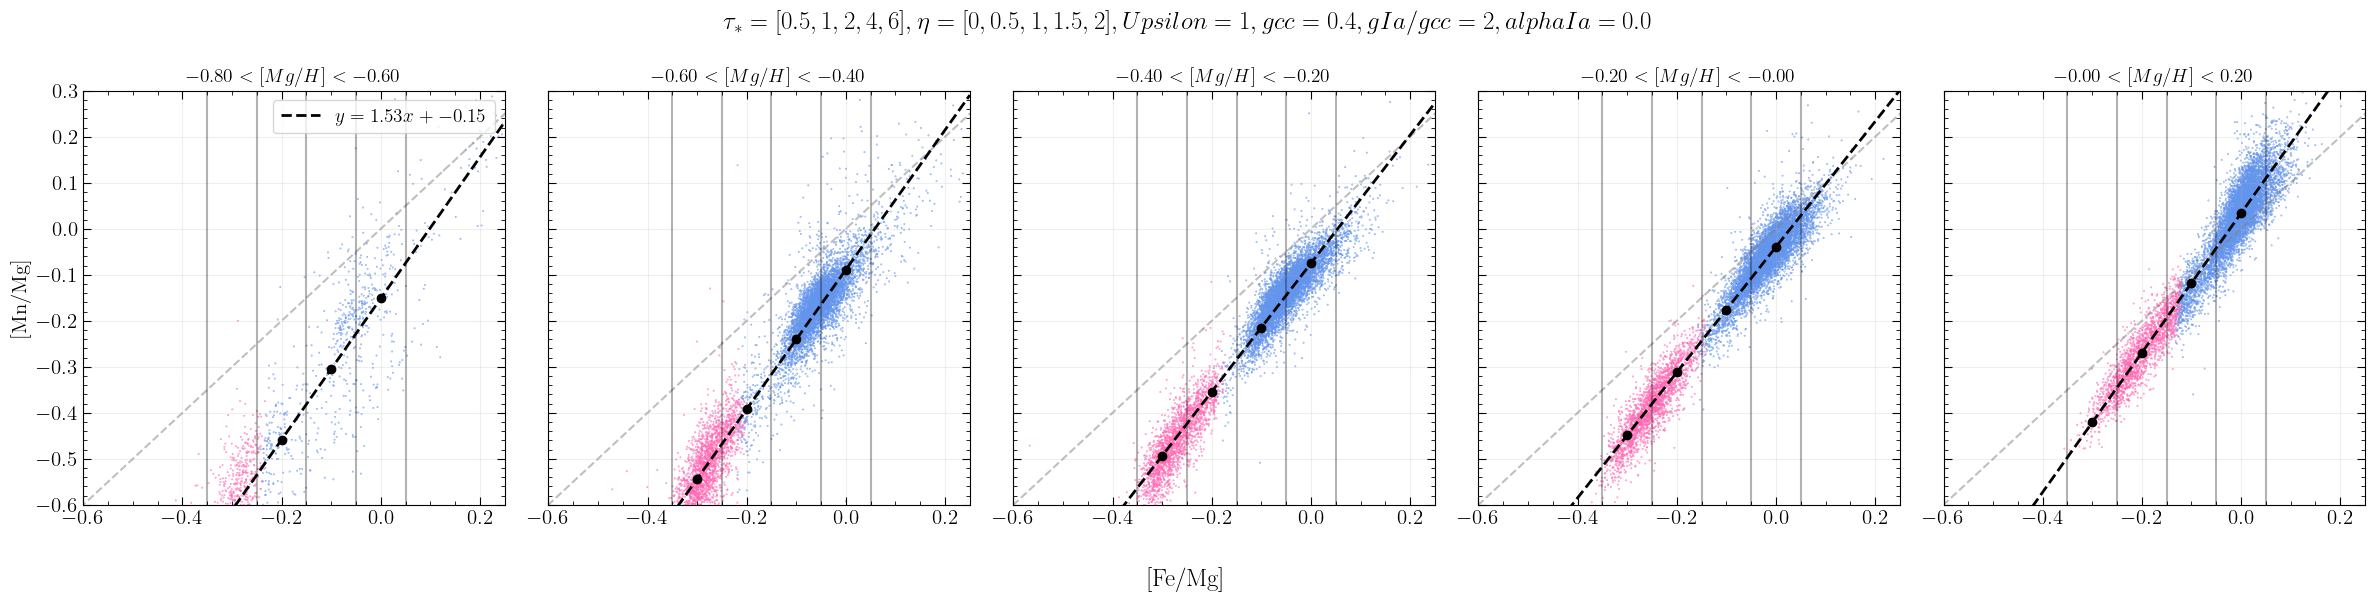

In [6]:
from scipy.stats import linregress

fig_x = 24
fig_y = 6


#fe_mg_bin_edges = np.arange(-0.40, 0.15, 0.15)
#fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

n_bins = len(axes)  # or len(mg_h_big_bin_centers)

slopes = np.zeros(n_bins)
intercepts = np.zeros(n_bins)

for i, ax in enumerate(axes):
    # Select data in this bin
    subset = data[data['MG_H_big_bin'] == i]
    downsampled_data = downsample(subset, 10000)

    x = downsampled_data['FE_MG']
    y = downsampled_data['MN_MG']

    # Scatter
    ax.scatter(x, y, s=0.1, color=downsampled_data['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # ---- LINEAR FIT ----
    # Remove NaNs just in case
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) > 2:
        slope, intercept, r_value, _, _ = linregress(x_fit, y_fit)
        slopes[i] = slope
        intercepts[i] = intercept

        # Plot fit
        xs_fit = np.linspace(-0.60, 0.25, 100)
        ys_fit = slope * xs_fit + intercept
        ax.plot(xs_fit, ys_fit, color='black', lw=2,
                label=rf'$y={slope:.2f}x+{intercept:.2f}$', linestyle='--')
        
        # Evaluate fit at bin centers
        y_centers = slope * fe_mg_bin_centers + intercept

        # Plot as points (recommended)
        ax.plot(fe_mg_bin_centers, y_centers, 'o', color='black', ms=6)
        ax.vlines(fe_mg_bin_edges,  ymin=-1.5, ymax=0.40, color='black', alpha=0.3)

        # Optional: connect them
        #ax.plot(fe_mg_bin_centers, y_centers, linestyle='--', color='black', alpha=0.7)

    if i == 0:
        ax.legend(loc='upper right', fontsize=14)
        ax.set_ylabel("[Mn/Mg]")

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.60, 0.30)


fig.supxlabel('[Fe/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \eta = {etas}, Upsilon = {gals_AA[0][0].Upsilon}, gcc = {gals_AA[0][0].g_cc_Mn}, gIa/gcc = {gals_AA[0][0].g_ratio_Mn}, alphaIa = {gals_AA[0][0].alpha_Ia_Mn}$")
plt.tight_layout()

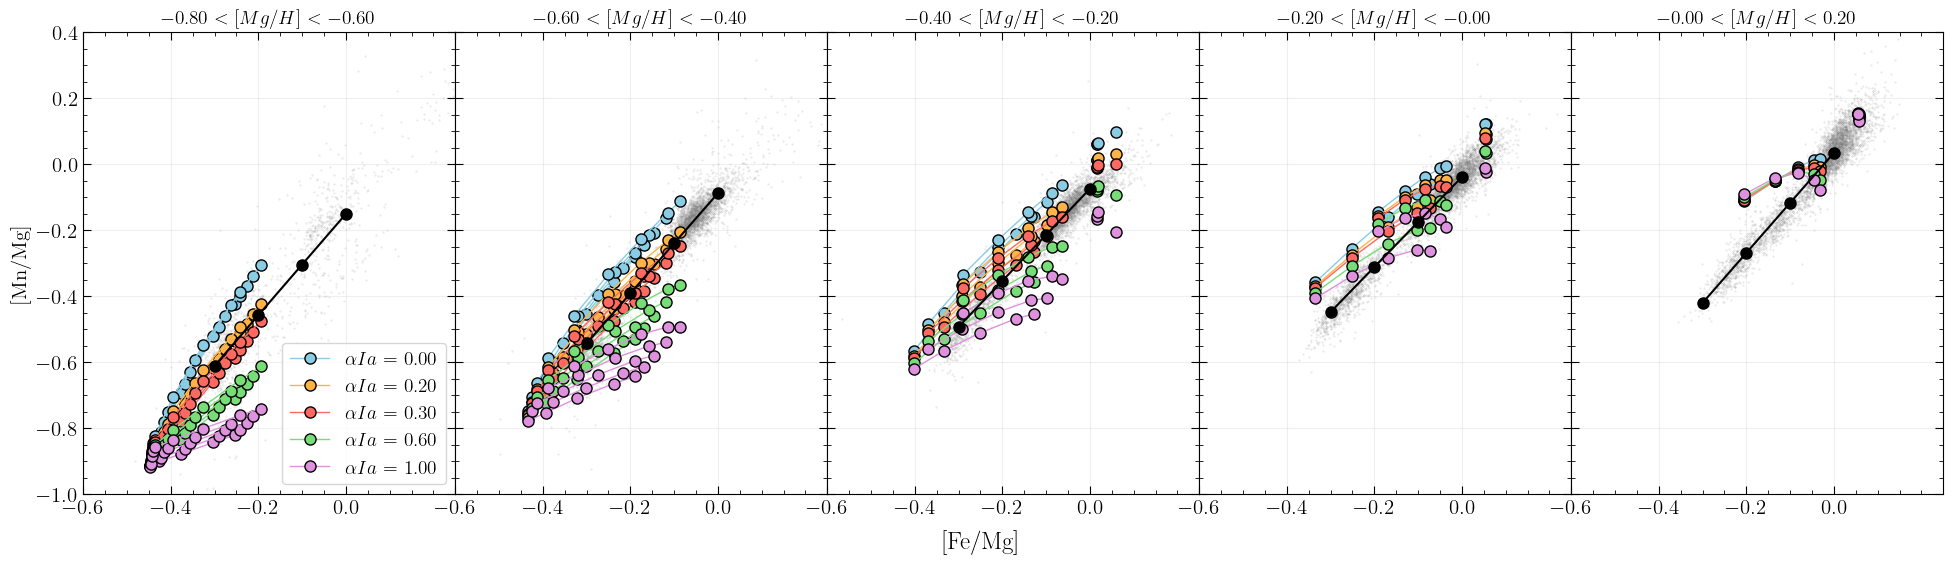

In [9]:
fig_x = 24
fig_y = 6

gals_list = [gals_AA, gals_AB, gals_AC, gals_AD, gals_AE]

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y),
                         sharex=True, sharey=True)
axes = axes.flatten()

# Define normalization and colormap ONCE (outside loop)

colors = ["#89CCE4",  # pastel blue
          '#FFB347',  # pastel orange
          '#FF6961',  # pastel red
          '#77DD77',  # pastel green
          "#DE92DE"]  # pastel purple



for i, ax in enumerate(axes):

    subset = data[data['MG_H_big_bin'] == i]

    downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
    ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

    # ---------- median computation (FULL DATA) ----------
    x = subset['FE_MG'].to_numpy()
    y = subset['MN_MG'].to_numpy()

    #ax.plot(fe_mg_bin_centers,medians,color='black',marker='o',markersize=8, zorder=5)
    y_centers = slopes[i] * fe_mg_bin_centers + intercepts[i]
    ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)


    for k in range(len(gals_list)):
        gals = gals_list[k]
        color = colors[k]
        # τ_* sequences for all gcc values
        gals_endpoints = {
            j: find_endpoints(gals[j], mg_h_big_bin_centers)
            for j in range(len(gals))
        }
        for j, (gals_j, endpoints_j) in enumerate(
            zip(gals, gals_endpoints.values())
        ):
            idxs = endpoints_j[i]

            fe_mg = [gal.Fe_Mg[idx] for gal, idx in zip(gals_j, idxs)]
            mn_mg = [gal.Mn_Mg[idx] for gal, idx in zip(gals_j, idxs)]
            example_gal = gals_j[0]
            ax.plot(fe_mg, mn_mg, marker='o', color=colors[k], linewidth=1,
                    label = fr"$\alpha Ia$ = {example_gal.alpha_Ia_Mn:.2f}" if j == 0 else None,
                    markeredgecolor='black', markersize=8)

    if i == 0:
        ax.legend(loc='lower right', fontsize=14)
        ax.set_ylabel('[Mn/Mg]')

     # Remove y-axis for all but first subplot                # remove right ticks

        #ax.spines['left'].set_linestyle((0, (3, 3)))
        #ax.spines['left'].set_alpha(0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.0, 0.40)


#cax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
#cbar = fig.colorbar(sm, cax=cax)
#cbar.set_label(r'$\alpha_{cc}$', fontsize=20)

fig.supxlabel('[Fe/Mg]')
fig.subplots_adjust(wspace=0)

plt.show()
